In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Impostazioni grafiche
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [7]:
# Definisci il percorso base
results_base = Path('../results')

# Definisci le configurazioni
loss_types = ['bce', 'contrastive', 'triplet']
dataset_combinations = ['iam_to_iam', 'iam_to_rimes', 'rimes_to_iam', 'rimes_to_rimes']
model_name = 'mobilenet_v3_small'

# Crea dizionario per memorizzare tutti i dati
all_results = {}

In [8]:
# Carica tutti i risultati
for loss in loss_types:
    all_results[loss] = {}
    
    for dataset_comb in dataset_combinations:
        experiment_name = f"{model_name}_{loss}_{dataset_comb}"
        experiment_path = results_base / loss / f"{loss}_experiments" / experiment_name
        
        # Carica final_metrics
        metrics_file = experiment_path / f"{experiment_name}_final_metrics.csv"
        history_file = experiment_path / f"{experiment_name}_history.csv"
        
        if metrics_file.exists() and history_file.exists():
            # Leggi metrics
            metrics_df = pd.read_csv(metrics_file)
            
            # Leggi history
            history_df = pd.read_csv(history_file)
            
            # Parsa genuine_vals e impostor_vals
            genuine_vals = ast.literal_eval(metrics_df['genuine_vals'].values[0])
            impostor_vals = ast.literal_eval(metrics_df['impostor_vals'].values[0])
            
            all_results[loss][dataset_comb] = {
                'metrics': metrics_df,
                'history': history_df,
                'genuine_vals': np.array(genuine_vals),
                'impostor_vals': np.array(impostor_vals)
            }
            
            print(f"✓ Caricato: {experiment_name}")
            print(f"  - Genuine scores: {len(genuine_vals)}")
            print(f"  - Impostor scores: {len(impostor_vals)}")
            print(f"  - Epochs: {len(history_df)}")
            print()

✓ Caricato: mobilenet_v3_small_bce_iam_to_iam
  - Genuine scores: 537
  - Impostor scores: 537
  - Epochs: 50

✓ Caricato: mobilenet_v3_small_bce_iam_to_rimes
  - Genuine scores: 7175
  - Impostor scores: 7175
  - Epochs: 16

✓ Caricato: mobilenet_v3_small_bce_rimes_to_iam
  - Genuine scores: 4051
  - Impostor scores: 4051
  - Epochs: 6

✓ Caricato: mobilenet_v3_small_bce_rimes_to_rimes
  - Genuine scores: 1444
  - Impostor scores: 1444
  - Epochs: 50

✓ Caricato: mobilenet_v3_small_contrastive_iam_to_iam
  - Genuine scores: 537
  - Impostor scores: 537
  - Epochs: 21

✓ Caricato: mobilenet_v3_small_contrastive_iam_to_rimes
  - Genuine scores: 7175
  - Impostor scores: 7175
  - Epochs: 8

✓ Caricato: mobilenet_v3_small_contrastive_rimes_to_iam
  - Genuine scores: 4051
  - Impostor scores: 4051
  - Epochs: 23

✓ Caricato: mobilenet_v3_small_contrastive_rimes_to_rimes
  - Genuine scores: 1444
  - Impostor scores: 1444
  - Epochs: 32

✓ Caricato: mobilenet_v3_small_triplet_iam_to_iam
  - 

In [9]:
def calculate_biometric_metrics(genuine_scores, impostor_scores):
    """Calcola tutte le metriche biometriche dagli score"""
    
    # Statistiche di base
    mu_genuine = np.mean(genuine_scores)
    mu_impostor = np.mean(impostor_scores)
    sigma_genuine = np.std(genuine_scores)
    sigma_impostor = np.std(impostor_scores)
    
    # D-prime e decidability
    d_prime = (mu_genuine - mu_impostor) / np.sqrt(0.5 * (sigma_genuine**2 + sigma_impostor**2))
    decidability = np.abs(mu_genuine - mu_impostor) / np.sqrt(0.5 * (sigma_genuine**2 + sigma_impostor**2))
    
    # Prepara dati per ROC
    y_true = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([genuine_scores, impostor_scores])
    
    # Calcola ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Calcola EER
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]
    
    # FAR @ 0.1% (0.001)
    far_001_idx = np.where(fpr <= 0.001)[0]
    if len(far_001_idx) > 0:
        far_001_idx = far_001_idx[-1]
        far_001_effective = fpr[far_001_idx]
        frr_at_far_001 = fnr[far_001_idx]
        gar_at_far_001 = tpr[far_001_idx]
        threshold_at_far_001 = thresholds[far_001_idx]
    else:
        far_001_effective = np.nan
        frr_at_far_001 = np.nan
        gar_at_far_001 = np.nan
        threshold_at_far_001 = np.nan
    
    # FAR @ 1% (0.01)
    far_01_idx = np.where(fpr <= 0.01)[0]
    if len(far_01_idx) > 0:
        far_01_idx = far_01_idx[-1]
        far_01_effective = fpr[far_01_idx]
        frr_at_far_01 = fnr[far_01_idx]
        gar_at_far_01 = tpr[far_01_idx]
        threshold_at_far_01 = thresholds[far_01_idx]
    else:
        far_01_effective = np.nan
        frr_at_far_01 = np.nan
        gar_at_far_01 = np.nan
        threshold_at_far_01 = np.nan
    
    # Accuracy al threshold EER
    predictions = (y_scores >= eer_threshold).astype(int)
    accuracy = np.mean(predictions == y_true)
    
    # Confusion matrix al threshold EER
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'auc': roc_auc,
        'eer': eer,
        'eer_threshold': eer_threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'd_prime': d_prime,
        'decidability': decidability,
        'mu_genuine': mu_genuine,
        'mu_impostor': mu_impostor,
        'sigma_genuine': sigma_genuine,
        'sigma_impostor': sigma_impostor,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'far_001_effective': far_001_effective,
        'frr_at_far_001': frr_at_far_001,
        'gar_at_far_001': gar_at_far_001,
        'threshold_at_far_001': threshold_at_far_001,
        'far_01_effective': far_01_effective,
        'frr_at_far_01': frr_at_far_01,
        'gar_at_far_01': gar_at_far_01,
        'threshold_at_far_01': threshold_at_far_01
    }

print("Funzione di calcolo metriche definita")

Funzione di calcolo metriche definita


In [10]:
# Calcola le metriche per ogni esperimento
computed_metrics = {}

for loss in loss_types:
    computed_metrics[loss] = {}
    
    for dataset_comb in dataset_combinations:
        if dataset_comb in all_results[loss]:
            genuine = all_results[loss][dataset_comb]['genuine_vals']
            impostor = all_results[loss][dataset_comb]['impostor_vals']
            
            metrics = calculate_biometric_metrics(genuine, impostor)
            computed_metrics[loss][dataset_comb] = metrics
            
            print(f"{loss} - {dataset_comb}:")
            print(f"  AUC: {metrics['auc']:.4f}")
            print(f"  EER: {metrics['eer']:.4f}")
            print(f"  D': {metrics['d_prime']:.4f}")
            print()

bce - iam_to_iam:
  AUC: 0.9877
  EER: 0.0493
  D': 4.2708

bce - iam_to_rimes:
  AUC: 0.5457
  EER: 0.4724
  D': 0.1527

bce - rimes_to_iam:
  AUC: 0.6099
  EER: 0.4048
  D': 0.3696

bce - rimes_to_rimes:
  AUC: 0.9212
  EER: 0.1371
  D': 2.3146

contrastive - iam_to_iam:
  AUC: 0.9786
  EER: 0.0736
  D': 2.4322

contrastive - iam_to_rimes:
  AUC: 0.6412
  EER: 0.3909
  D': 0.3529

contrastive - rimes_to_iam:
  AUC: 0.8268
  EER: 0.2509
  D': 1.0797

contrastive - rimes_to_rimes:
  AUC: 0.8952
  EER: 0.1759
  D': 1.5370

triplet - iam_to_iam:
  AUC: 0.8762
  EER: 0.2123
  D': 1.3392

triplet - iam_to_rimes:
  AUC: 0.6265
  EER: 0.4092
  D': 0.4080

triplet - rimes_to_iam:
  AUC: 0.7983
  EER: 0.2728
  D': 0.5980

triplet - rimes_to_rimes:
  AUC: 0.7388
  EER: 0.3127
  D': 0.5714



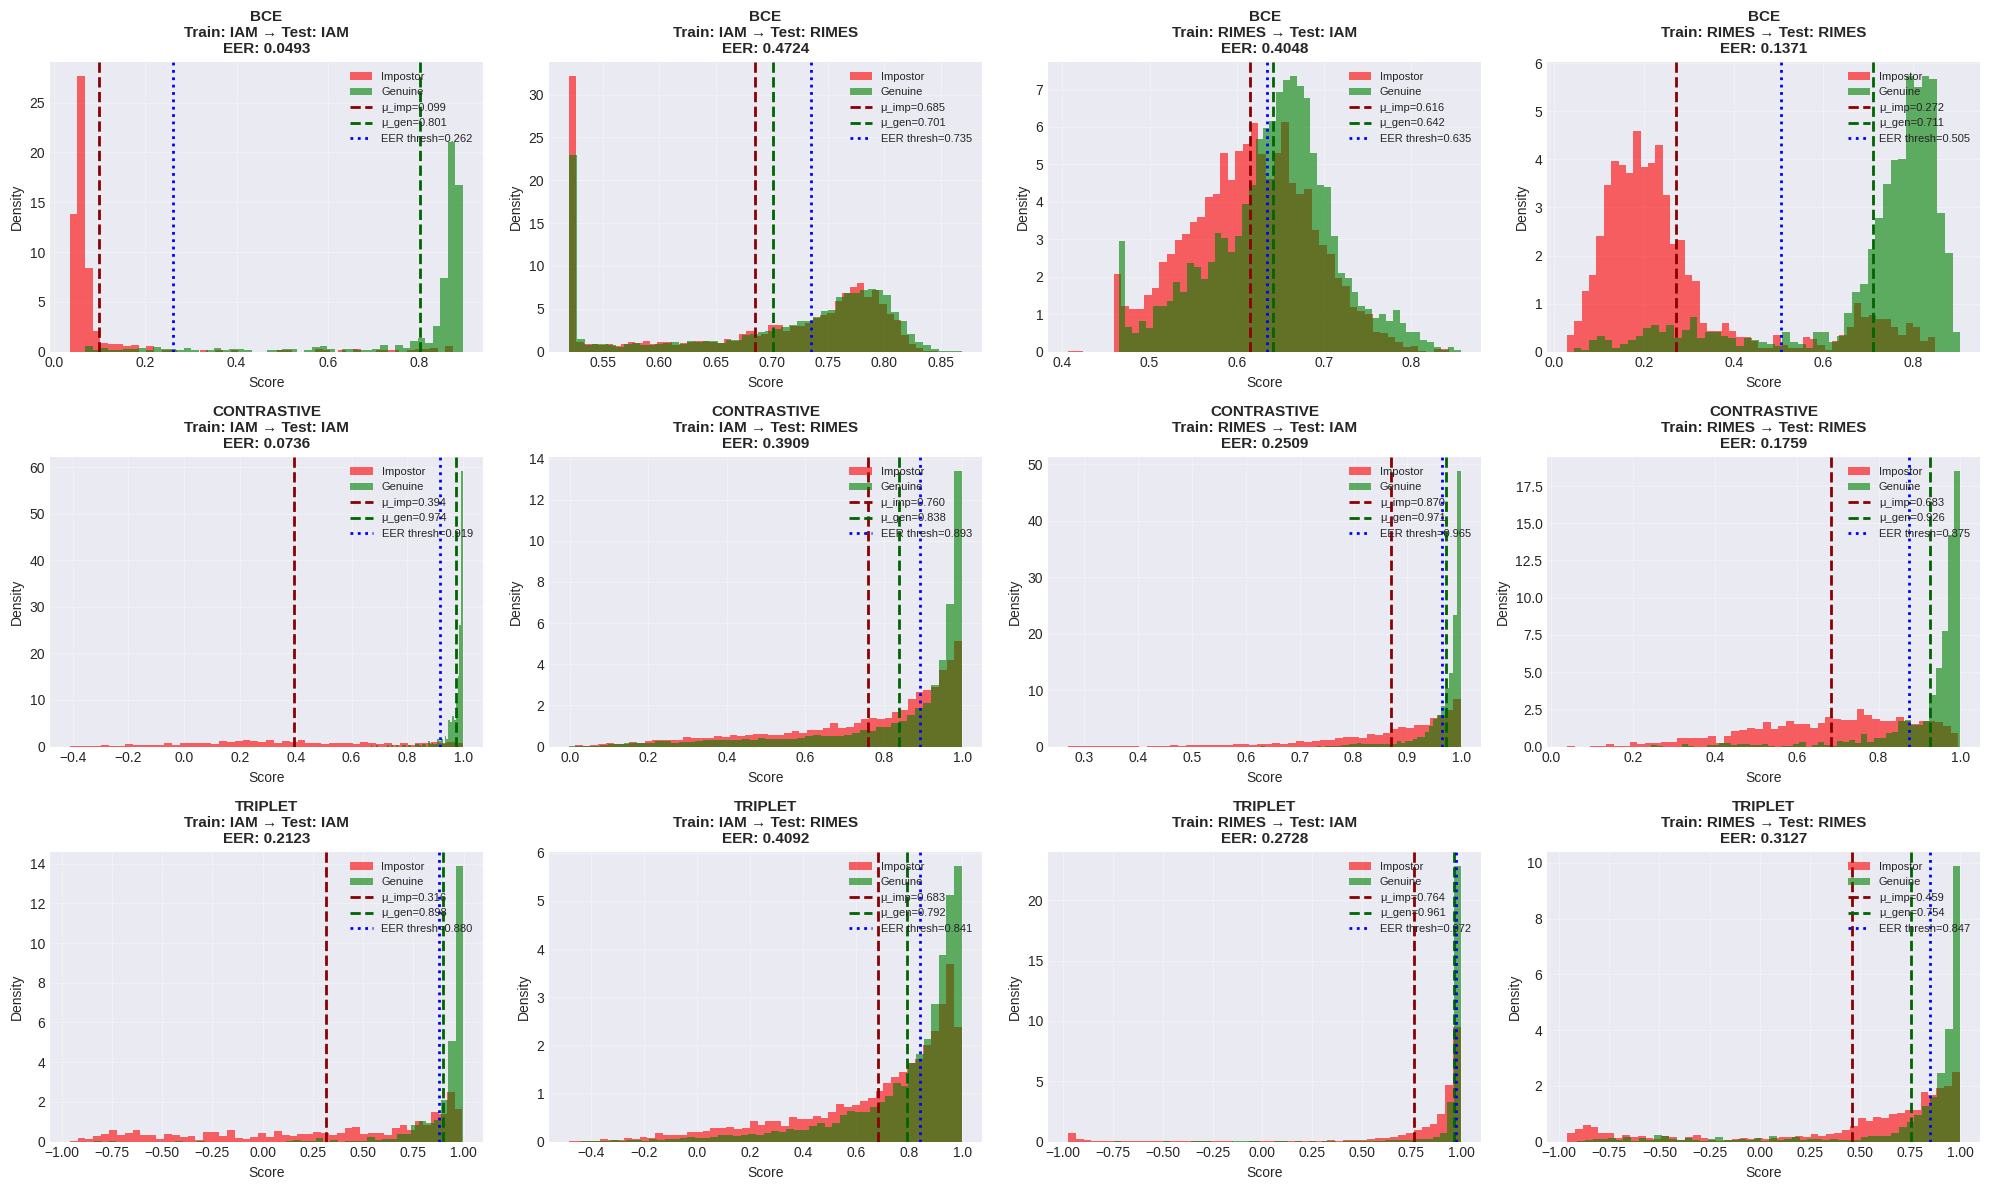

In [11]:
# Plot delle distribuzioni - 4 colonne per dataset combination
fig, axes = plt.subplots(len(loss_types), len(dataset_combinations), 
                         figsize=(20, 4*len(loss_types)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        ax = axes[i, j] if len(loss_types) > 1 else axes[j]
        
        if dataset_comb in all_results[loss]:
            genuine = all_results[loss][dataset_comb]['genuine_vals']
            impostor = all_results[loss][dataset_comb]['impostor_vals']
            
            # Histogrammi
            ax.hist(impostor, bins=50, alpha=0.6, label='Impostor', color='red', density=True)
            ax.hist(genuine, bins=50, alpha=0.6, label='Genuine', color='green', density=True)
            
            # Linee verticali per le medie
            ax.axvline(np.mean(impostor), color='darkred', linestyle='--', linewidth=2, label=f'μ_imp={np.mean(impostor):.3f}')
            ax.axvline(np.mean(genuine), color='darkgreen', linestyle='--', linewidth=2, label=f'μ_gen={np.mean(genuine):.3f}')
            
            # EER threshold
            eer_thresh = computed_metrics[loss][dataset_comb]['eer_threshold']
            ax.axvline(eer_thresh, color='blue', linestyle=':', linewidth=2, label=f'EER thresh={eer_thresh:.3f}')
            
            # Titolo e labels
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f'{loss.upper()}\nTrain: {train_ds.upper()} → Test: {test_ds.upper()}\nEER: {computed_metrics[loss][dataset_comb]["eer"]:.4f}', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('Score', fontsize=10)
            ax.set_ylabel('Density', fontsize=10)
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

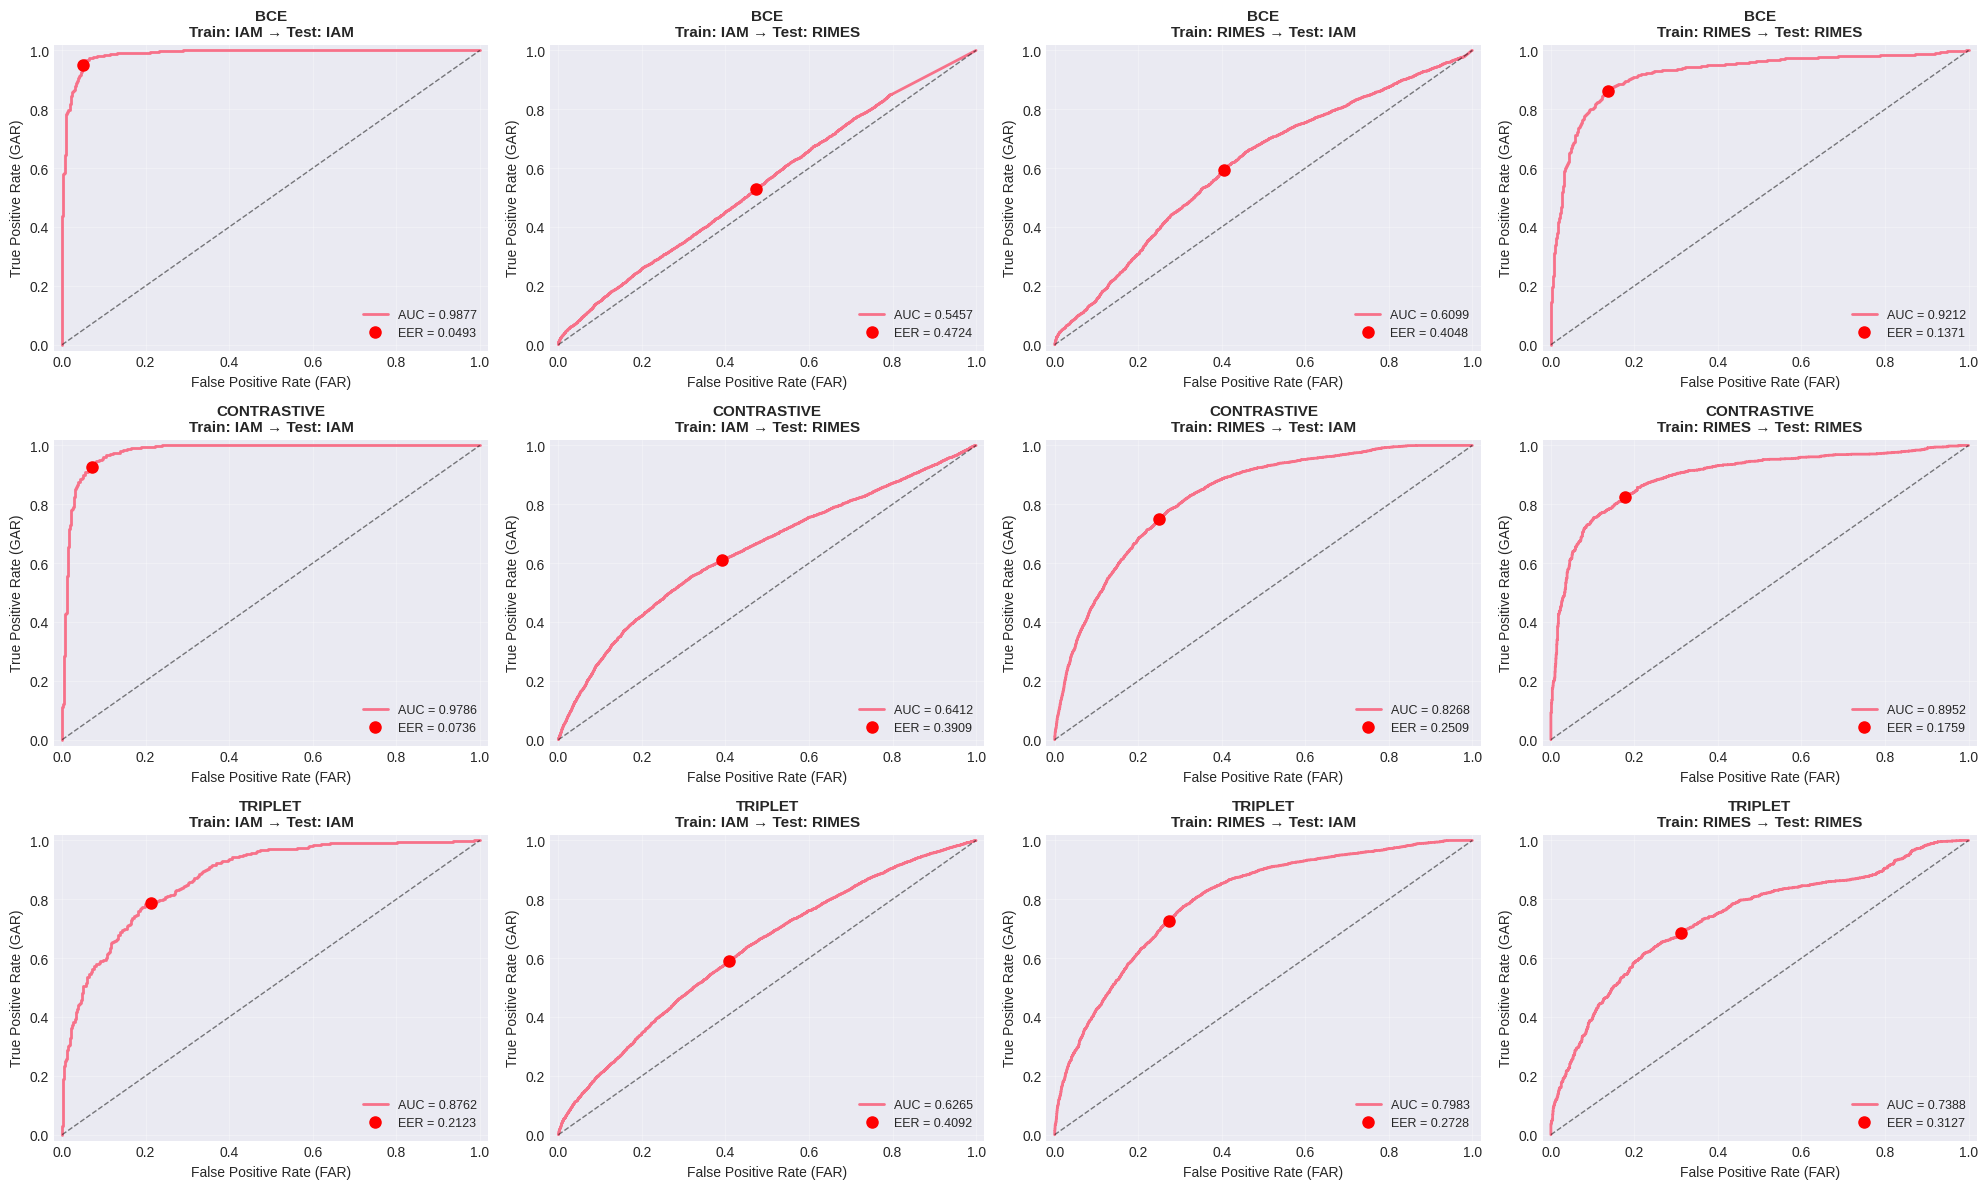

In [12]:
# ROC Curves - 4 colonne per dataset combination
fig, axes = plt.subplots(len(loss_types), len(dataset_combinations), 
                         figsize=(20, 4*len(loss_types)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        ax = axes[i, j] if len(loss_types) > 1 else axes[j]
        
        if dataset_comb in computed_metrics[loss]:
            metrics = computed_metrics[loss][dataset_comb]
            
            # Plot ROC curve
            ax.plot(metrics['fpr'], metrics['tpr'], linewidth=2, 
                   label=f'AUC = {metrics["auc"]:.4f}')
            
            # Linea diagonale
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
            
            # Punto EER
            eer_idx = np.nanargmin(np.absolute((1-metrics['tpr']) - metrics['fpr']))
            ax.plot(metrics['fpr'][eer_idx], metrics['tpr'][eer_idx], 'ro', 
                   markersize=8, label=f'EER = {metrics["eer"]:.4f}')
            
            # Titolo e labels
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f'{loss.upper()}\nTrain: {train_ds.upper()} → Test: {test_ds.upper()}', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('False Positive Rate (FAR)', fontsize=10)
            ax.set_ylabel('True Positive Rate (GAR)', fontsize=10)
            ax.legend(fontsize=9, loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

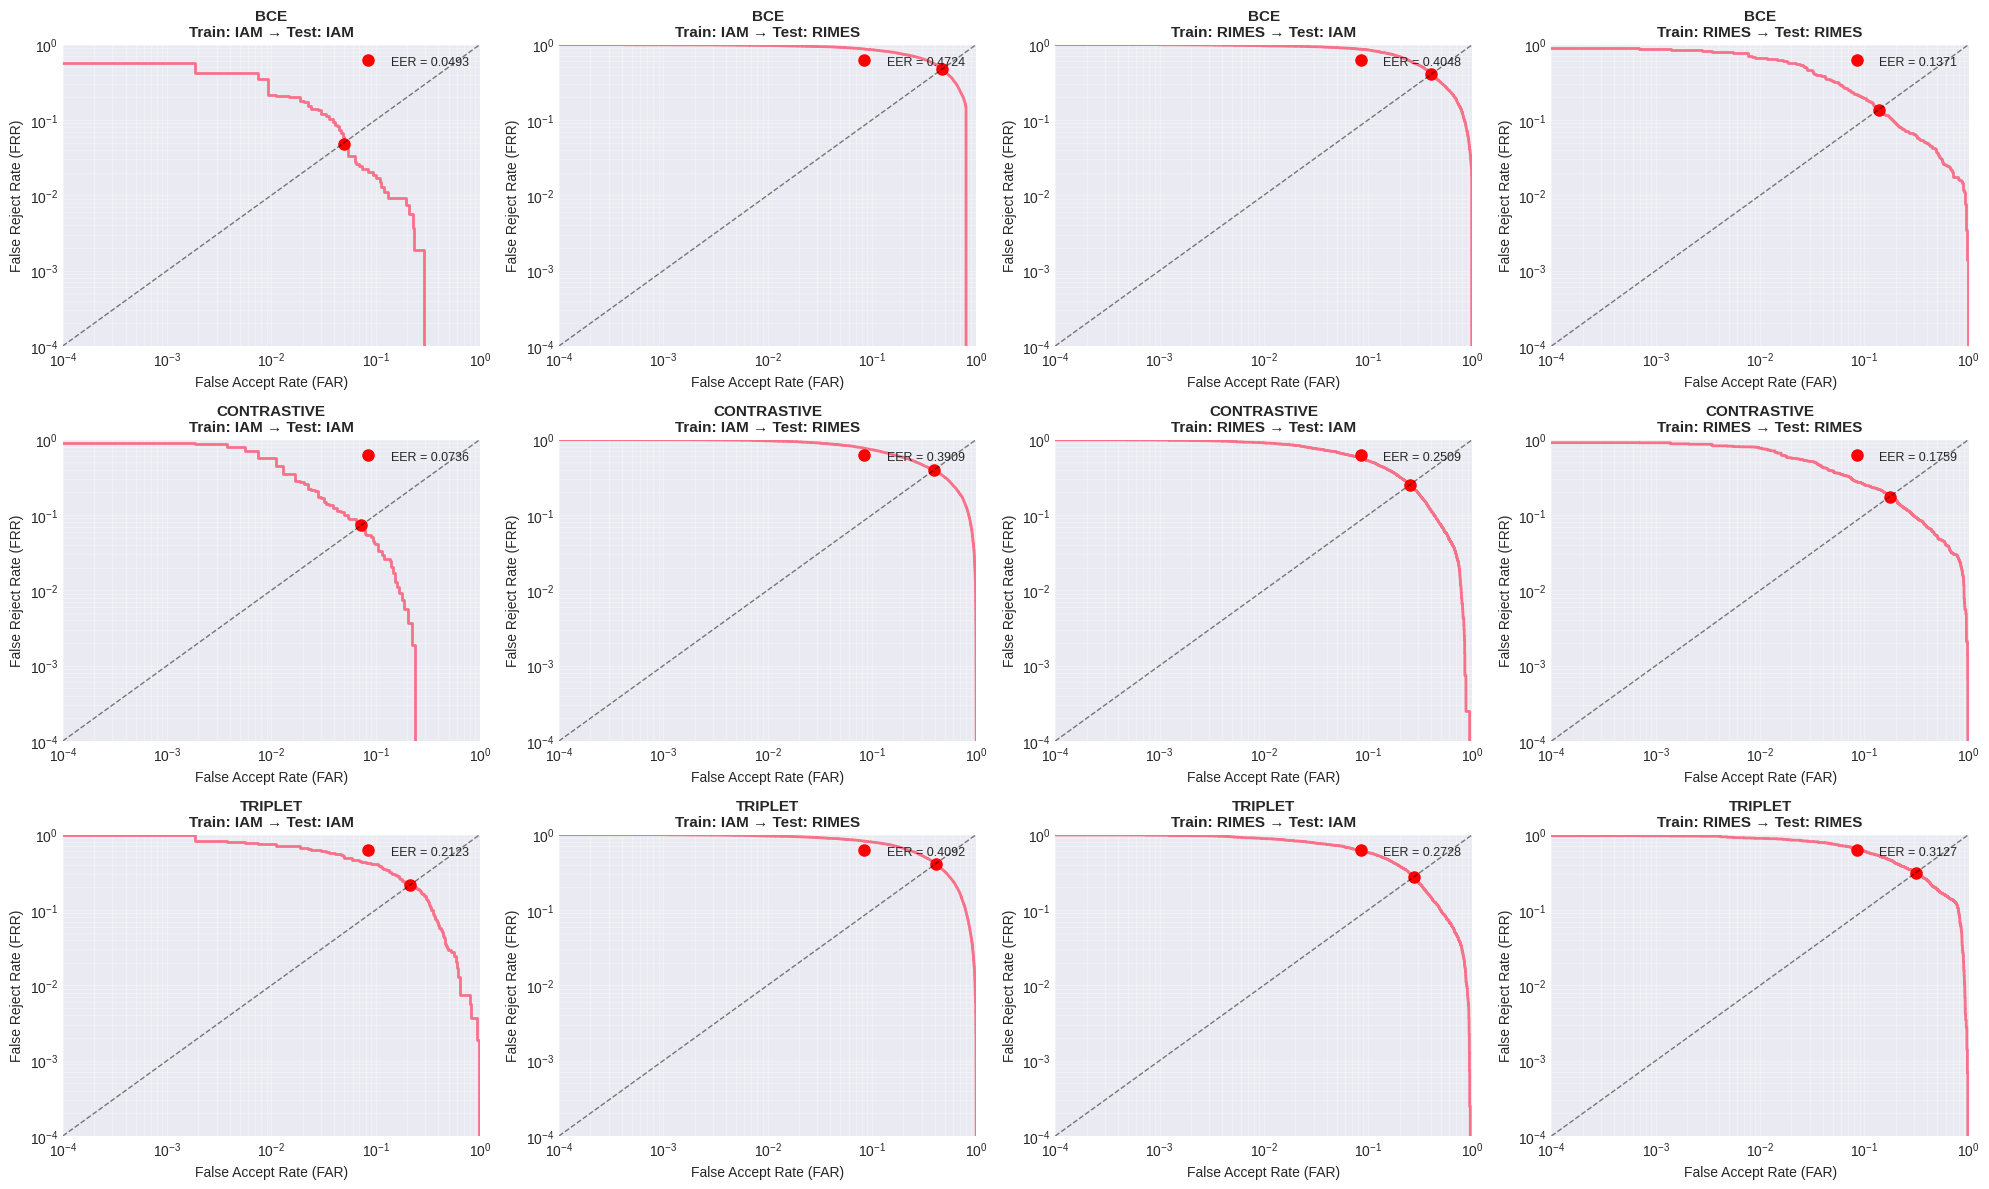

In [13]:
# DET Curves - 4 colonne per dataset combination
fig, axes = plt.subplots(len(loss_types), len(dataset_combinations), 
                         figsize=(20, 4*len(loss_types)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        ax = axes[i, j] if len(loss_types) > 1 else axes[j]
        
        if dataset_comb in computed_metrics[loss]:
            metrics = computed_metrics[loss][dataset_comb]
            
            # Calcola FRR
            frr = 1 - metrics['tpr']
            
            # Plot DET curve (log scale)
            ax.loglog(metrics['fpr'], frr, linewidth=2)
            
            # Punto EER
            eer_idx = np.nanargmin(np.absolute(frr - metrics['fpr']))
            ax.plot(metrics['fpr'][eer_idx], frr[eer_idx], 'ro', 
                   markersize=8, label=f'EER = {metrics["eer"]:.4f}')
            
            # Linea diagonale
            ax.plot([1e-4, 1], [1e-4, 1], 'k--', linewidth=1, alpha=0.5)
            
            # Titolo e labels
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f'{loss.upper()}\nTrain: {train_ds.upper()} → Test: {test_ds.upper()}', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('False Accept Rate (FAR)', fontsize=10)
            ax.set_ylabel('False Reject Rate (FRR)', fontsize=10)
            ax.legend(fontsize=9, loc='upper right')
            ax.grid(True, alpha=0.3, which='both')
            ax.set_xlim([1e-4, 1])
            ax.set_ylim([1e-4, 1])

plt.tight_layout()
plt.savefig('det_curves.png', dpi=300, bbox_inches='tight')
plt.show()

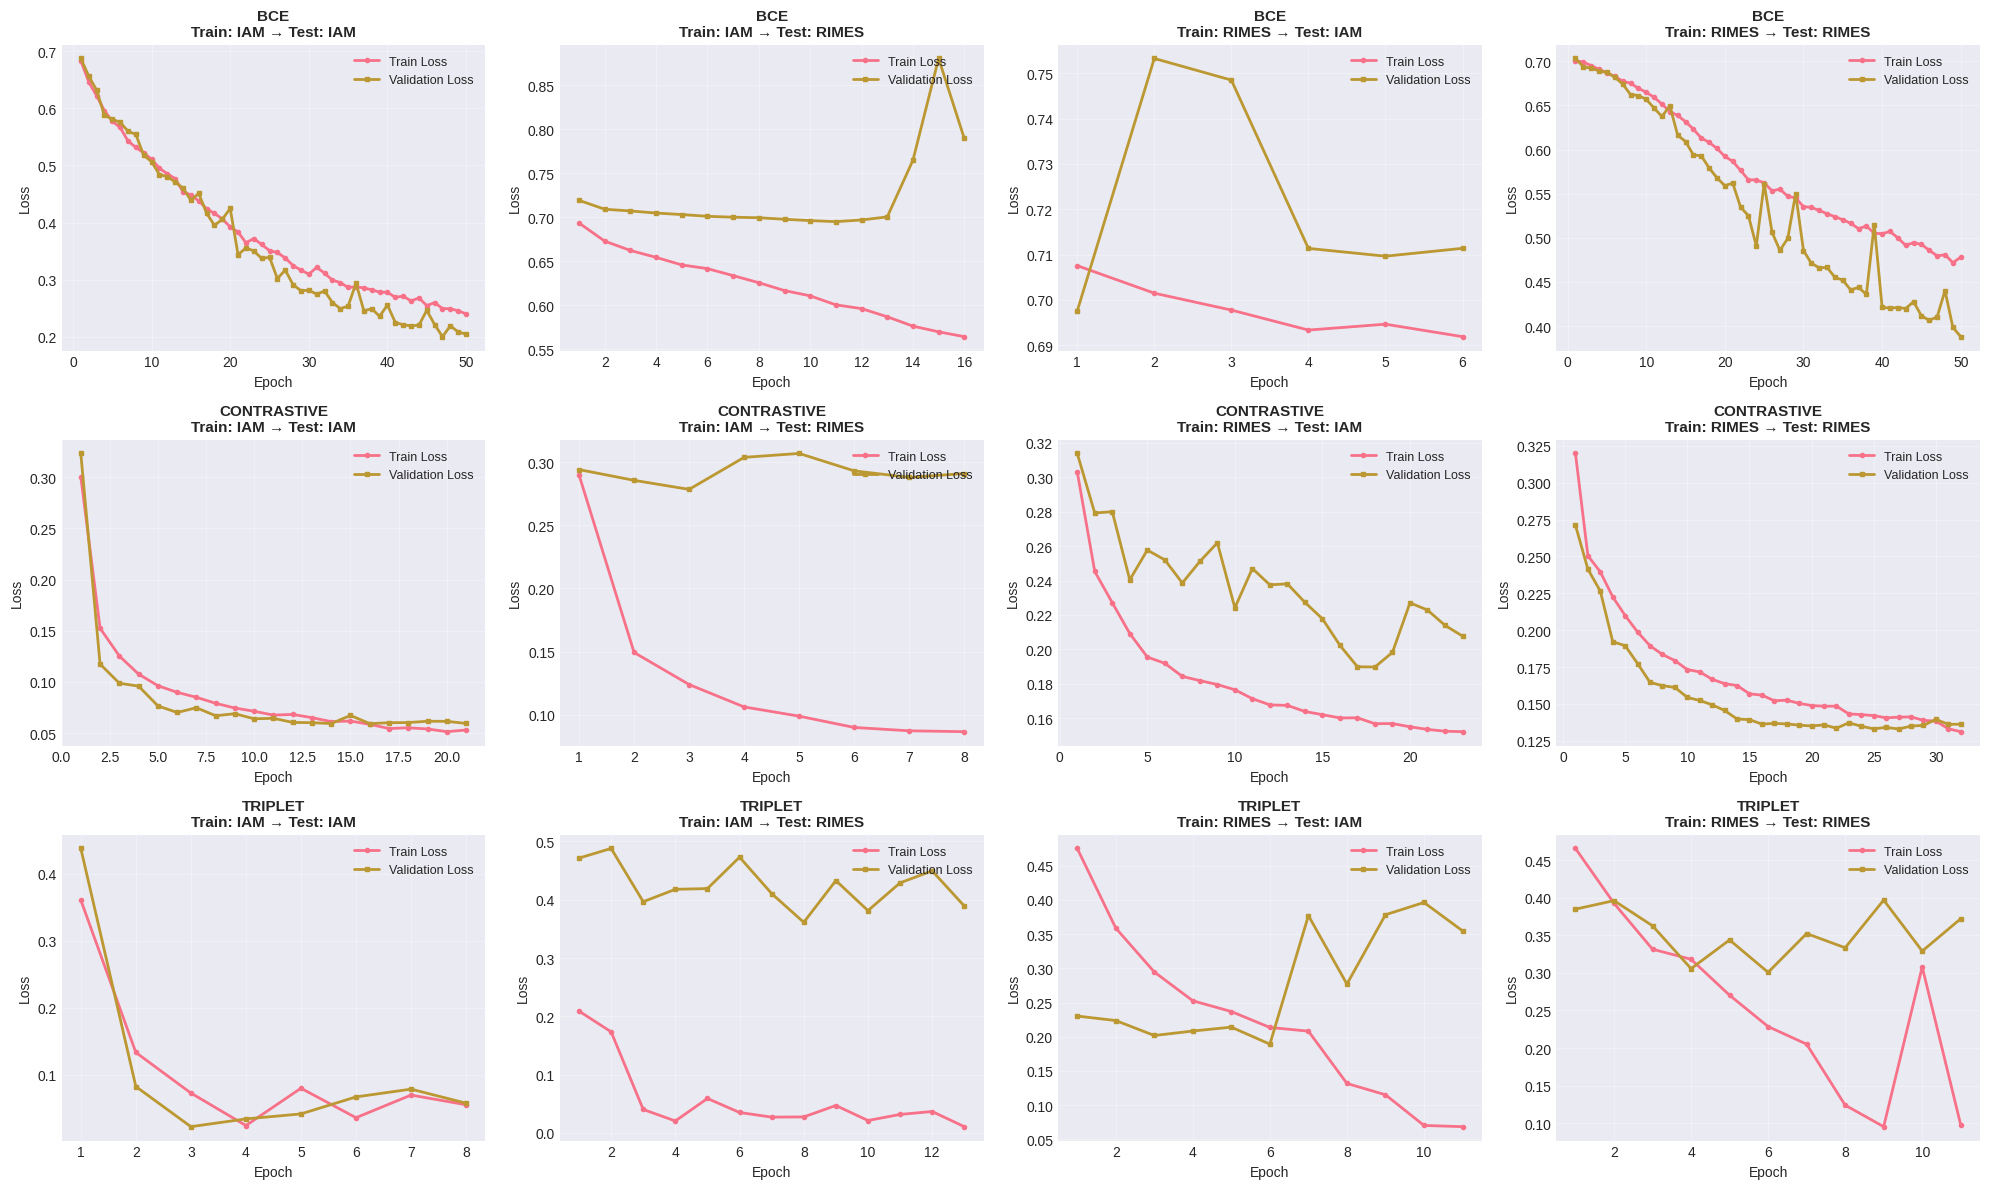

In [14]:
# Training History - 4 colonne per dataset combination
fig, axes = plt.subplots(len(loss_types), len(dataset_combinations), 
                         figsize=(20, 4*len(loss_types)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        ax = axes[i, j] if len(loss_types) > 1 else axes[j]
        
        if dataset_comb in all_results[loss]:
            history = all_results[loss][dataset_comb]['history']
            
            # Plot training e validation loss
            ax.plot(history['epoch'], history['train_loss'], 
                   linewidth=2, label='Train Loss', marker='o', markersize=3)
            ax.plot(history['epoch'], history['val_loss'], 
                   linewidth=2, label='Validation Loss', marker='s', markersize=3)
            
            # Titolo e labels
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f'{loss.upper()}\nTrain: {train_ds.upper()} → Test: {test_ds.upper()}', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('Epoch', fontsize=10)
            ax.set_ylabel('Loss', fontsize=10)
            ax.legend(fontsize=9, loc='upper right')
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Analisi Same Dataset (train e test sullo stesso dataset)
same_dataset_results = []

for loss in loss_types:
    for dataset_comb in ['iam_to_iam', 'rimes_to_rimes']:
        if dataset_comb in computed_metrics[loss]:
            metrics = computed_metrics[loss][dataset_comb]
            same_dataset_results.append({
                'Loss': loss.upper(),
                'Dataset': dataset_comb.split('_to_')[0].upper(),
                'AUC': f"{metrics['auc']:.4f}",
                'EER': f"{metrics['eer']:.4f}",
                'D-prime': f"{metrics['d_prime']:.4f}",
                'Decidability': f"{metrics['decidability']:.4f}",
                'Accuracy': f"{metrics['accuracy']:.4f}",
                'F1-Score': f"{metrics['f1']:.4f}",
                'GAR@FAR=0.1%': f"{metrics['gar_at_far_001']:.4f}" if not np.isnan(metrics['gar_at_far_001']) else 'N/A',
                'GAR@FAR=1%': f"{metrics['gar_at_far_01']:.4f}" if not np.isnan(metrics['gar_at_far_01']) else 'N/A'
            })

same_df = pd.DataFrame(same_dataset_results)
print("=" * 150)
print("ANALISI SAME DATASET (Train e Test sullo stesso dataset)")
print("=" * 150)
print(same_df.to_string(index=False))
print("\n")

ANALISI SAME DATASET (Train e Test sullo stesso dataset)
       Loss Dataset    AUC    EER D-prime Decidability Accuracy F1-Score GAR@FAR=0.1% GAR@FAR=1%
        BCE     IAM 0.9877 0.0493  4.2708       4.2708   0.9507   0.9507       0.4376     0.7840
        BCE   RIMES 0.9212 0.1371  2.3146       2.3146   0.8629   0.8629       0.1191     0.3310
CONTRASTIVE     IAM 0.9786 0.0736  2.4322       2.4322   0.9264   0.9264       0.1117     0.4302
CONTRASTIVE   RIMES 0.8952 0.1759  1.5370       1.5370   0.8241   0.8242       0.0942     0.2313
    TRIPLET     IAM 0.8762 0.2123  1.3392       1.3392   0.7877   0.7877       0.0279     0.2588
    TRIPLET   RIMES 0.7388 0.3127  0.5714       0.5714   0.6873   0.6872       0.0395     0.1108




In [16]:
# Analisi Cross Dataset (train e test su dataset diversi)
cross_dataset_results = []

for loss in loss_types:
    for dataset_comb in ['iam_to_rimes', 'rimes_to_iam']:
        if dataset_comb in computed_metrics[loss]:
            metrics = computed_metrics[loss][dataset_comb]
            train_ds, test_ds = dataset_comb.split('_to_')
            cross_dataset_results.append({
                'Loss': loss.upper(),
                'Train→Test': f"{train_ds.upper()}→{test_ds.upper()}",
                'AUC': f"{metrics['auc']:.4f}",
                'EER': f"{metrics['eer']:.4f}",
                'D-prime': f"{metrics['d_prime']:.4f}",
                'Decidability': f"{metrics['decidability']:.4f}",
                'Accuracy': f"{metrics['accuracy']:.4f}",
                'F1-Score': f"{metrics['f1']:.4f}",
                'GAR@FAR=0.1%': f"{metrics['gar_at_far_001']:.4f}" if not np.isnan(metrics['gar_at_far_001']) else 'N/A',
                'GAR@FAR=1%': f"{metrics['gar_at_far_01']:.4f}" if not np.isnan(metrics['gar_at_far_01']) else 'N/A'
            })

cross_df = pd.DataFrame(cross_dataset_results)
print("=" * 150)
print("ANALISI CROSS DATASET (Train e Test su dataset diversi)")
print("=" * 150)
print(cross_df.to_string(index=False))
print("\n")

ANALISI CROSS DATASET (Train e Test su dataset diversi)
       Loss Train→Test    AUC    EER D-prime Decidability Accuracy F1-Score GAR@FAR=0.1% GAR@FAR=1%
        BCE  IAM→RIMES 0.5457 0.4724  0.1527       0.1527   0.5276   0.5276       0.0085     0.0304
        BCE  RIMES→IAM 0.6099 0.4048  0.3696       0.3696   0.5952   0.5952       0.0059     0.0380
CONTRASTIVE  IAM→RIMES 0.6412 0.3909  0.3529       0.3529   0.6091   0.6091       0.0049     0.0396
CONTRASTIVE  RIMES→IAM 0.8268 0.2509  1.0797       1.0797   0.7491   0.7490       0.0170     0.0970
    TRIPLET  IAM→RIMES 0.6265 0.4092  0.4080       0.4080   0.5908   0.5908       0.0057     0.0436
    TRIPLET  RIMES→IAM 0.7983 0.2728  0.5980       0.5980   0.7272   0.7272       0.0225     0.1177




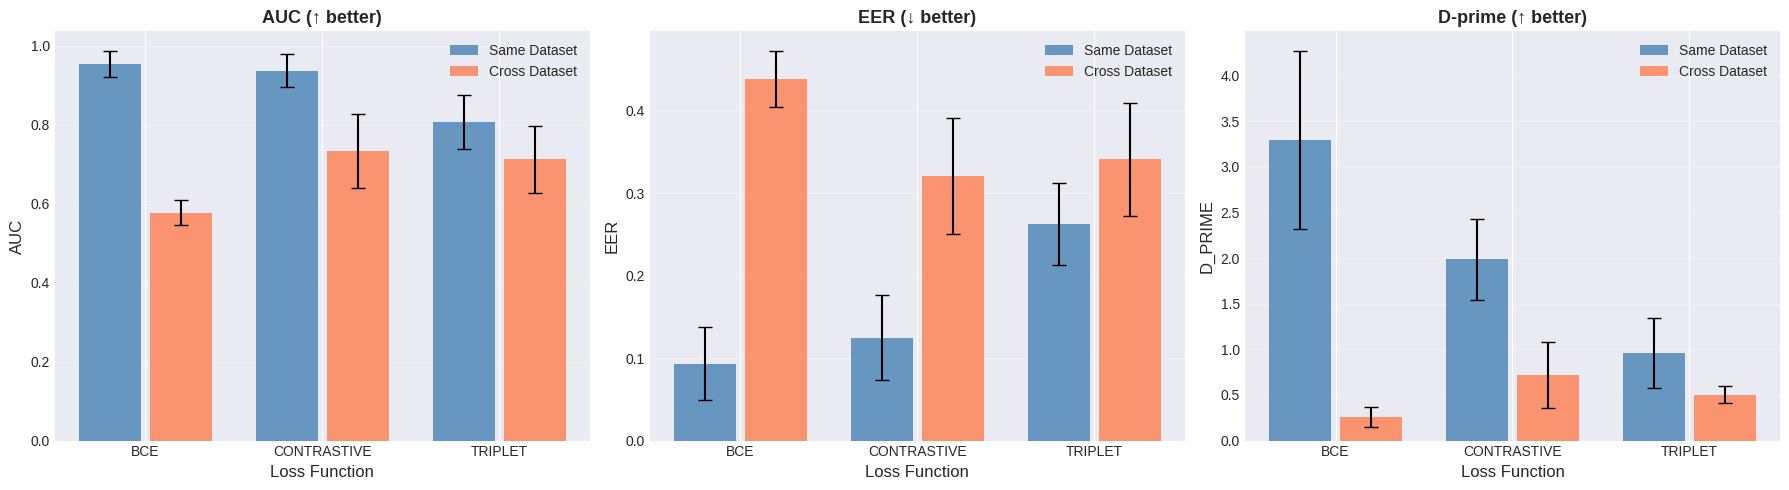

In [17]:
# Confronto Same vs Cross Dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_compare = ['auc', 'eer', 'd_prime']
titles = ['AUC (↑ better)', 'EER (↓ better)', 'D-prime (↑ better)']

for idx, (metric, title) in enumerate(zip(metrics_to_compare, titles)):
    ax = axes[idx]
    
    x_pos = 0
    x_labels = []
    x_ticks = []
    
    for loss in loss_types:
        # Same dataset
        same_vals = []
        for ds in ['iam_to_iam', 'rimes_to_rimes']:
            if ds in computed_metrics[loss]:
                same_vals.append(computed_metrics[loss][ds][metric])
        
        # Cross dataset
        cross_vals = []
        for ds in ['iam_to_rimes', 'rimes_to_iam']:
            if ds in computed_metrics[loss]:
                cross_vals.append(computed_metrics[loss][ds][metric])
        
        # Plot bars
        if same_vals:
            ax.bar(x_pos, np.mean(same_vals), width=0.35, 
                  label='Same Dataset' if x_pos == 0 else '', 
                  color='steelblue', alpha=0.8)
            ax.errorbar(x_pos, np.mean(same_vals), yerr=np.std(same_vals), 
                       fmt='none', color='black', capsize=5)
        
        if cross_vals:
            ax.bar(x_pos + 0.4, np.mean(cross_vals), width=0.35, 
                  label='Cross Dataset' if x_pos == 0 else '', 
                  color='coral', alpha=0.8)
            ax.errorbar(x_pos + 0.4, np.mean(cross_vals), yerr=np.std(cross_vals), 
                       fmt='none', color='black', capsize=5)
        
        x_labels.append(loss.upper())
        x_ticks.append(x_pos + 0.2)
        x_pos += 1
    
    ax.set_xlabel('Loss Function', fontsize=12)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('same_vs_cross_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

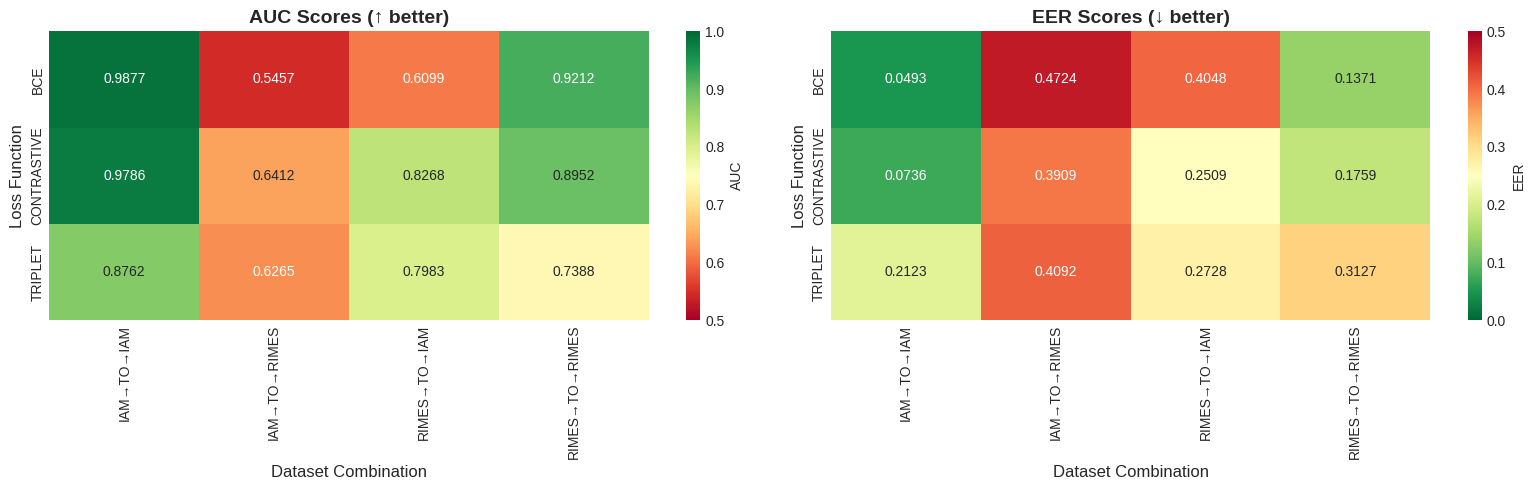

In [18]:
# Heatmap AUC
auc_matrix = np.zeros((len(loss_types), len(dataset_combinations)))
eer_matrix = np.zeros((len(loss_types), len(dataset_combinations)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        if dataset_comb in computed_metrics[loss]:
            auc_matrix[i, j] = computed_metrics[loss][dataset_comb]['auc']
            eer_matrix[i, j] = computed_metrics[loss][dataset_comb]['eer']
        else:
            auc_matrix[i, j] = np.nan
            eer_matrix[i, j] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap AUC
sns.heatmap(auc_matrix, annot=True, fmt='.4f', cmap='RdYlGn', 
            xticklabels=[dc.replace('_', '→').upper() for dc in dataset_combinations],
            yticklabels=[l.upper() for l in loss_types],
            ax=axes[0], cbar_kws={'label': 'AUC'}, vmin=0.5, vmax=1.0)
axes[0].set_title('AUC Scores (↑ better)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dataset Combination', fontsize=12)
axes[0].set_ylabel('Loss Function', fontsize=12)

# Heatmap EER
sns.heatmap(eer_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            xticklabels=[dc.replace('_', '→').upper() for dc in dataset_combinations],
            yticklabels=[l.upper() for l in loss_types],
            ax=axes[1], cbar_kws={'label': 'EER'}, vmin=0.0, vmax=0.5)
axes[1].set_title('EER Scores (↓ better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dataset Combination', fontsize=12)
axes[1].set_ylabel('Loss Function', fontsize=12)

plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Analisi statistica delle distribuzioni
print("=" * 100)
print("ANALISI STATISTICA DELLE DISTRIBUZIONI DI SCORE")
print("=" * 100)

for loss in loss_types:
    print(f"\n{'='*50}")
    print(f"LOSS: {loss.upper()}")
    print(f"{'='*50}")
    
    for dataset_comb in dataset_combinations:
        if dataset_comb in all_results[loss]:
            genuine = all_results[loss][dataset_comb]['genuine_vals']
            impostor = all_results[loss][dataset_comb]['impostor_vals']
            metrics = computed_metrics[loss][dataset_comb]
            
            train_ds, test_ds = dataset_comb.split('_to_')
            print(f"\n{train_ds.upper()} → {test_ds.upper()}:")
            print(f"  Genuine scores:")
            print(f"    - Mean: {metrics['mu_genuine']:.4f}")
            print(f"    - Std:  {metrics['sigma_genuine']:.4f}")
            print(f"    - Min:  {np.min(genuine):.4f}")
            print(f"    - Max:  {np.max(genuine):.4f}")
            print(f"    - Median: {np.median(genuine):.4f}")
            
            print(f"  Impostor scores:")
            print(f"    - Mean: {metrics['mu_impostor']:.4f}")
            print(f"    - Std:  {metrics['sigma_impostor']:.4f}")
            print(f"    - Min:  {np.min(impostor):.4f}")
            print(f"    - Max:  {np.max(impostor):.4f}")
            print(f"    - Median: {np.median(impostor):.4f}")
            
            print(f"  Separazione:")
            print(f"    - D-prime: {metrics['d_prime']:.4f}")
            print(f"    - Decidability: {metrics['decidability']:.4f}")
            print(f"    - Distance (μ_gen - μ_imp): {metrics['mu_genuine'] - metrics['mu_impostor']:.4f}")

ANALISI STATISTICA DELLE DISTRIBUZIONI DI SCORE

LOSS: BCE

IAM → IAM:
  Genuine scores:
    - Mean: 0.8014
    - Std:  0.1812
    - Min:  0.0689
    - Max:  0.8958
    - Median: 0.8709
  Impostor scores:
    - Mean: 0.0987
    - Std:  0.1460
    - Min:  0.0347
    - Max:  0.8741
    - Median: 0.0604
  Separazione:
    - D-prime: 4.2708
    - Decidability: 4.2708
    - Distance (μ_gen - μ_imp): 0.7028

IAM → RIMES:
  Genuine scores:
    - Mean: 0.7013
    - Std:  0.1034
    - Min:  0.5194
    - Max:  0.8692
    - Median: 0.7418
  Impostor scores:
    - Mean: 0.6852
    - Std:  0.1073
    - Min:  0.5194
    - Max:  0.8480
    - Median: 0.7262
  Separazione:
    - D-prime: 0.1527
    - Decidability: 0.1527
    - Distance (μ_gen - μ_imp): 0.0161

RIMES → IAM:
  Genuine scores:
    - Mean: 0.6416
    - Std:  0.0712
    - Min:  0.4645
    - Max:  0.8578
    - Median: 0.6491
  Impostor scores:
    - Mean: 0.6155
    - Std:  0.0700
    - Min:  0.4063
    - Max:  0.8435
    - Median: 0.6176
  

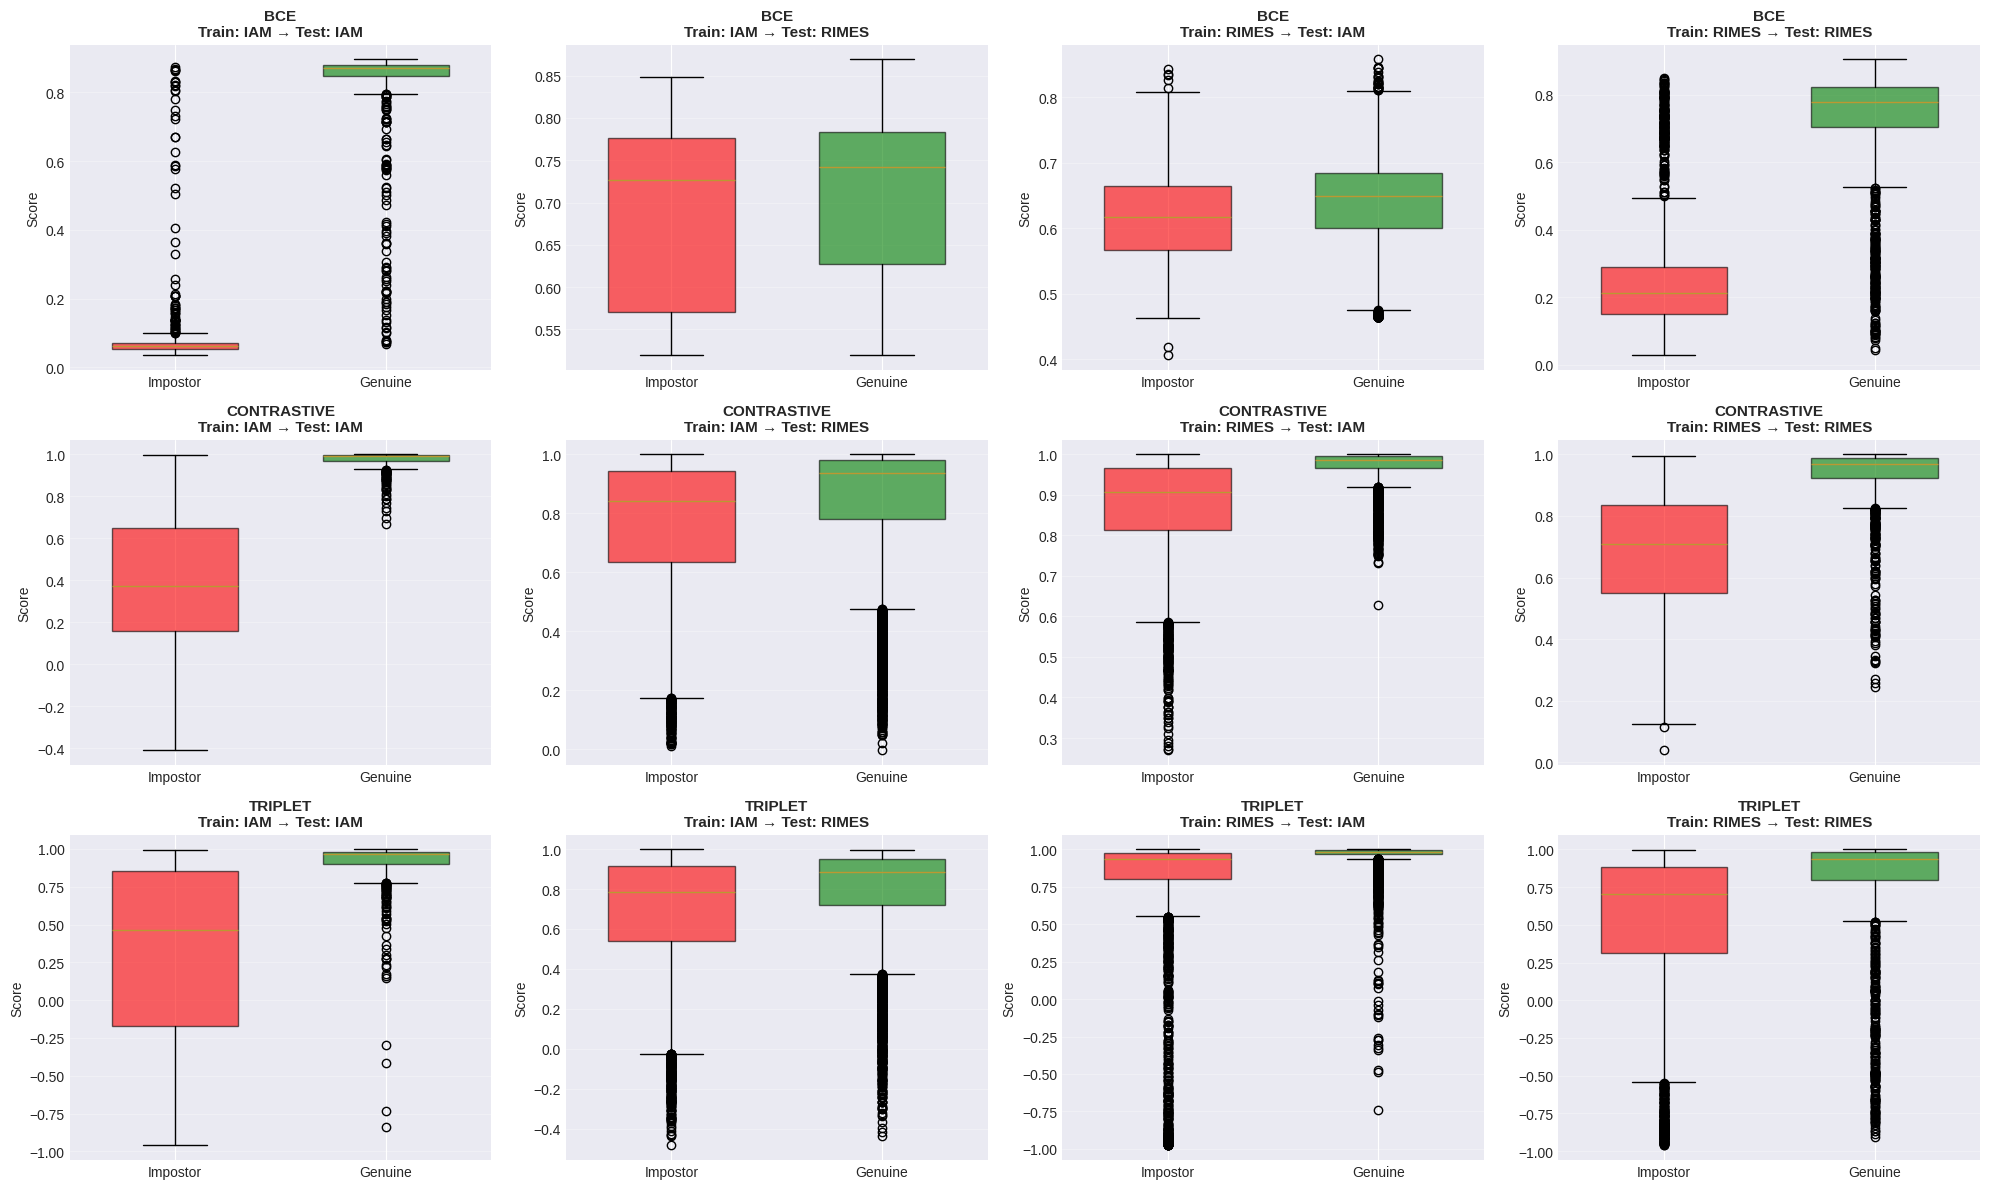

In [20]:
# Box plots delle distribuzioni
fig, axes = plt.subplots(len(loss_types), len(dataset_combinations), 
                         figsize=(20, 4*len(loss_types)))

for i, loss in enumerate(loss_types):
    for j, dataset_comb in enumerate(dataset_combinations):
        ax = axes[i, j] if len(loss_types) > 1 else axes[j]
        
        if dataset_comb in all_results[loss]:
            genuine = all_results[loss][dataset_comb]['genuine_vals']
            impostor = all_results[loss][dataset_comb]['impostor_vals']
            
            # Prepara dati per box plot
            data_to_plot = [impostor, genuine]
            
            # Box plot
            bp = ax.boxplot(data_to_plot, labels=['Impostor', 'Genuine'],
                           patch_artist=True, widths=0.6)
            
            # Colora i box
            colors = ['red', 'green']
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            
            # Titolo e labels
            train_ds, test_ds = dataset_comb.split('_to_')
            ax.set_title(f'{loss.upper()}\nTrain: {train_ds.upper()} → Test: {test_ds.upper()}', 
                        fontsize=11, fontweight='bold')
            ax.set_ylabel('Score', fontsize=10)
            ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('score_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()